# Cloud Cover (clt)

clt with R1 and donut 2-3 and sea ice 3R and no land mass in 3R 

#### data import

In [1]:
import intake
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import matplotlib.colors as colors
from shapely.geometry import Polygon, Point, box
from shapely import contains_xy
import time
from scipy.stats import linregress
import sys
sys.path.append("/home/b/b383696/02_Functions/Eddy_Track")
from function_mature_eddy import get_mature_eddies_fast
from function_track_calculate import mature_eddies_track_fast
sys.path.append("/home/b/b383696/02_Functions")
from function_area_Rradii_shift_new_Version import eddyR_donut_sst
from function_area_Rradii_shift_new_Version import eddyR_donut_shift
from function_donut import dif_mean_calculation
import pandas as pd

In [2]:
#import data with ice free 3R (and no land mass)
edso_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso_ac_3R_0_ocean.nc")
edso_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso_c_3R_0_ocean.nc")

In [3]:
eerie_cat=intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
da_atmos = eerie_cat["dkrz"]["disk"]["model-output"]["icon-esm-er"]["hist-1950"]["v20240618"]["atmos"]["gr025"]["2d_daily_mean"].to_dask()
da_ocean = eerie_cat["dkrz"]["disk"]["model-output"]["icon-esm-er"]["hist-1950"]["v20240618"]["ocean"]["gr025"]["2d_daily_mean"].to_dask()

In [4]:
#select atmos and ocean data for SO
da_atmos_so = da_atmos.where(da_atmos.lat < -50, drop = True)
da_ocean_so = da_ocean.where(da_ocean.lat < -50, drop = True)

In [7]:
#import data
sst1_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/sst1_dn23_ac.nc")
sst1_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/sst1_dn23_c.nc")

In [8]:
#import data
clt1_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/clt1_dn23_ac.nc")
clt1_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/clt1_dn23_c.nc")

In [9]:
#import data (generated in this notebook)
edso1_clt_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac.nc")
edso1_clt_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c.nc")

In [10]:
#import data
edso1_clt_q75 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_q75.nc")

In [11]:
#import data data
edso1_clt_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20.nc")

In [12]:
#import data
edso1_clt_ac_q75 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac_q75.nc")
edso1_clt_c_q75 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c_q75.nc")

In [13]:
#import data warm/cold
edso1_clt_q75_e20_warm = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_warm.nc")
edso1_clt_q75_e20_cold = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_cold.nc")

In [14]:
#import data
edso1_clt_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_ac_q75_e20.nc")
edso1_clt_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_c_q75_e20.nc")

#### statistical analysis

In [39]:
import statsmodels.api as sm

y = df["dif_clt"]
X = sm.add_constant(df["dif_sst"])

ols = sm.OLS(y, X).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                dif_clt   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     95.60
Date:                Fri, 23 Jan 2026   Prob (F-statistic):           1.46e-22
Time:                        10:35:26   Log-Likelihood:             1.0986e+05
No. Observations:               60786   AIC:                        -2.197e+05
Df Residuals:                   60784   BIC:                        -2.197e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.000      7.853      0.0

In [18]:
resid = model.resid

print("Min/max:", np.min(resid), np.max(resid))
print("Unique values:", len(np.unique(resid)))
print("NaNs:", np.isnan(resid).sum())
print("Shape:", resid.shape)


Min/max: -0.5047449889046229 0.3806976398554244
Unique values: 60786
NaNs: 0
Shape: (60786,)


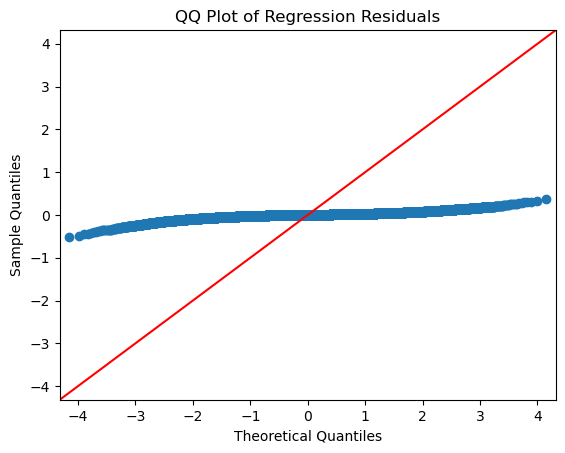

In [15]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(resid, line='45')
plt.title("QQ Plot of Regression Residuals")
plt.show()


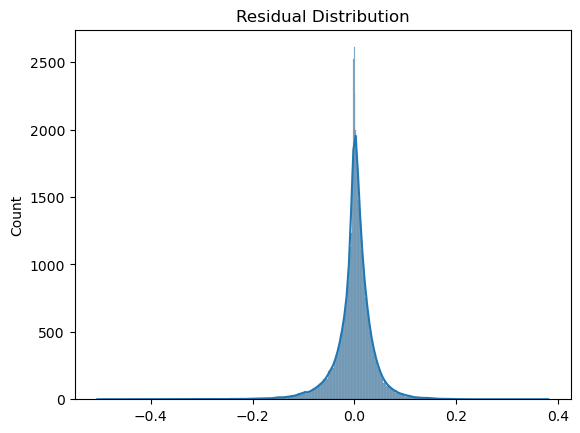

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(resid, kde=True)
plt.title("Residual Distribution")
plt.show()


#### calculate dif_sst with 1R and donut 2-3

In [5]:
sst1_ac = eddyR_donut_sst(da_ocean_so, edso_ac, 3, 2, 1)

In [6]:
sst1_c = eddyR_donut_sst(da_ocean_so, edso_c, 3, 2, 1)

In [8]:
#### select warm AC and cold C (no shift, all data)
sst1_ac_warm = sst1_ac.where(sst1_ac.dif_sst > 0, drop = True)
sst1_ac_cold = sst1_ac.where(sst1_ac.dif_sst < 0, drop = True)
sst1_c_warm = sst1_c.where(sst1_c.dif_sst > 0, drop = True)
sst1_c_cold = sst1_c.where(sst1_c.dif_sst < 0, drop = True)

In [9]:
sst1_ac_warm

<xarray.Dataset>
Dimensions:            (obs: 1179827)
Coordinates:
  * obs                (obs) int64 3 4 5 6 7 ... 1741145 1741146 1741147 1741148
Data variables:
    sst_mean_ed        (obs) float64 4.328 4.242 3.898 ... 6.27 6.486 6.386
    sst_npoints_ed     (obs) float64 6.0 6.0 6.0 5.0 6.0 ... 4.0 2.0 3.0 3.0 3.0
    sst_mean_donut     (obs) float64 3.945 3.971 3.807 ... 5.986 6.036 6.109
    sst_npoints_donut  (obs) float64 29.0 39.0 34.0 20.0 ... 12.0 13.0 13.0 13.0
    dif_sst            (obs) float64 0.3831 0.2716 0.09163 ... 0.4498 0.2765
    ID                 (obs) float64 4.0 5.0 6.0 ... 1.987e+06 1.987e+06

In [10]:
sst1_ac_cold

<xarray.Dataset>
Dimensions:            (obs: 561314)
Coordinates:
  * obs                (obs) int64 0 1 2 11 ... 1741149 1741150 1741151 1741152
Data variables:
    sst_mean_ed        (obs) float64 2.889 3.52 3.978 ... 1.756 1.839 2.202
    sst_npoints_ed     (obs) float64 4.0 4.0 4.0 27.0 24.0 ... 3.0 3.0 4.0 2.0
    sst_mean_donut     (obs) float64 3.223 3.798 4.057 ... 2.519 2.469 2.873
    sst_npoints_donut  (obs) float64 16.0 17.0 20.0 127.0 ... 19.0 17.0 14.0
    dif_sst            (obs) float64 -0.3339 -0.2778 -0.07883 ... -0.63 -0.6715
    ID                 (obs) float64 1.0 2.0 3.0 ... 1.987e+06 1.987e+06

In [11]:
sst1_c_warm

<xarray.Dataset>
Dimensions:            (obs: 559278)
Coordinates:
  * obs                (obs) int64 3 4 5 6 7 ... 1661588 1661589 1661590 1661591
Data variables:
    sst_mean_ed        (obs) float64 2.297 2.211 2.102 ... 2.984 2.843 2.898
    sst_npoints_ed     (obs) float64 6.0 3.0 4.0 3.0 3.0 ... 4.0 5.0 8.0 7.0
    sst_mean_donut     (obs) float64 2.179 2.167 2.088 ... 2.959 2.817 2.86
    sst_npoints_donut  (obs) float64 26.0 14.0 18.0 13.0 ... 24.0 26.0 38.0 31.0
    dif_sst            (obs) float64 0.1187 0.04379 0.01432 ... 0.02598 0.03798
    ID                 (obs) float64 12.0 15.0 16.0 ... 1.95e+06 1.95e+06

In [12]:
sst1_c_cold

<xarray.Dataset>
Dimensions:            (obs: 1102293)
Coordinates:
  * obs                (obs) int64 0 1 2 17 ... 1661600 1661601 1661602 1661603
Data variables:
    sst_mean_ed        (obs) float64 2.079 2.005 2.239 ... 5.254 5.442 5.523
    sst_npoints_ed     (obs) float64 8.0 8.0 4.0 5.0 6.0 ... 50.0 51.0 48.0 48.0
    sst_mean_donut     (obs) float64 2.201 2.053 2.254 ... 5.419 5.643 5.634
    sst_npoints_donut  (obs) float64 40.0 34.0 22.0 20.0 ... 256.0 238.0 254.0
    dif_sst            (obs) float64 -0.1219 -0.04753 ... -0.2014 -0.1106
    ID                 (obs) float64 8.0 9.0 11.0 ... 1.95e+06 1.95e+06 1.95e+06

In [13]:
#export data
sst1_ac.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/sst1_dn23_ac.nc")
sst1_c.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/sst1_dn23_c.nc")

#### calculate dif_clt with 1R and donut 2-3

In [14]:
clt1_ac = eddyR_donut_shift(da_atmos_so, edso_ac, "clt", 3, 2, 0, 1)

In [15]:
clt1_c = eddyR_donut_shift(da_atmos_so, edso_c, "clt", 3, 2, 0, 1)

In [17]:
#export data
clt1_ac.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/clt1_dn23_ac.nc")
clt1_c.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/clt1_dn23_c.nc")

#### combine and calculate dif_clt 

In [18]:
edso1_clt_ac = dif_mean_calculation(edso_ac, sst1_ac, clt1_ac, "clt", 0)

In [19]:
edso1_clt_c = dif_mean_calculation(edso_c, sst1_c, clt1_c, "clt", 0)

In [20]:
edso1_clt_c

<xarray.Dataset>
Dimensions:                        (obs: 1661571, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 8.0 9.0 ... 1.95e+06 1.95e+06
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 -0.0442 -0.0326 ... -0.1393
    cost_association               (obs) float32 0.2921 0.2675 ... 9.969e+36
    effective_area                 (obs) float32 1.764e+09 ... 1.738e+10
    effective_contour_height       (obs) float32 0.056 0.044 ... -0.06 -0.06
    effective_contour_latitude     (obs, NbSample) float64 -69.76 ... -61.86
    effective_contour_longitude    (obs, NbSample) float64 355.2 355.2 ... 237.2
    ...                             ...
    dif_clt                        (obs) float64 -0.1473 -0.006723 ... 0.004964
    sst_mean_ed                    (obs) float64 2.079 2.005 ... 5.442 5.523
    sst_npoints_ed                 (obs) float64 8.0 8.0 4.0 ... 51.0 48.0 48.0
    sst_mean_donut                 (obs) float64 2.201 2.053 ... 5.643 5.634
    sst_npoints_donut              (obs) float64 40.0 34.0 22.0 ... 238.0 254.0
    dif_sst                        (obs) float64 -0.1219 -0.04753 ... -0.1106
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Cyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T08:03:27Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [21]:
#export data
edso1_clt_ac.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac.nc")
edso1_clt_c.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c.nc")

#### select warm/cold eddies

In [22]:
#### select warm AC and cold C (no shift, all data)
edso1_clt_ac_warm = edso1_clt_ac.where(edso1_clt_ac.dif_sst > 0, drop = True)
edso1_clt_ac_cold = edso1_clt_ac.where(edso1_clt_ac.dif_sst < 0, drop = True)
edso1_clt_c_warm = edso1_clt_c.where(edso1_clt_c.dif_sst > 0, drop = True)
edso1_clt_c_cold = edso1_clt_c.where(edso1_clt_c.dif_sst < 0, drop = True)

In [23]:
edso1_clt_ac_warm

<xarray.Dataset>
Dimensions:                        (obs: 1179827, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 4.0 5.0 ... 1.987e+06 1.987e+06
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 0.0173 0.0198 ... 0.0091 0.0092
    cost_association               (obs) float32 0.2485 0.1088 ... 9.969e+36
    effective_area                 (obs) float32 1.226e+09 ... 7.081e+08
    effective_contour_height       (obs) float32 -0.048 -0.048 ... 0.078 0.08
    effective_contour_latitude     (obs, NbSample) float64 -75.99 ... -69.04
    effective_contour_longitude    (obs, NbSample) float64 203.0 203.2 ... 285.8
    ...                             ...
    dif_clt                        (obs) float64 0.03333 0.01966 ... 0.0004203
    sst_mean_ed                    (obs) float64 4.328 4.242 ... 6.486 6.386
    sst_npoints_ed                 (obs) float64 6.0 6.0 6.0 5.0 ... 3.0 3.0 3.0
    sst_mean_donut                 (obs) float64 3.945 3.971 ... 6.036 6.109
    sst_npoints_donut              (obs) float64 29.0 39.0 34.0 ... 13.0 13.0
    dif_sst                        (obs) float64 0.3831 0.2716 ... 0.4498 0.2765
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [24]:
edso1_clt_ac_cold

<xarray.Dataset>
Dimensions:                        (obs: 561314, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 1.0 2.0 ... 1.987e+06 1.987e+06
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 0.008 0.01 ... 0.0324 0.0275
    cost_association               (obs) float32 0.2152 0.2833 ... 9.969e+36
    effective_area                 (obs) float32 5.428e+08 ... 5.388e+08
    effective_contour_height       (obs) float32 -0.048 -0.048 ... 0.188 0.196
    effective_contour_latitude     (obs, NbSample) float64 -75.94 ... -69.06
    effective_contour_longitude    (obs, NbSample) float64 203.5 203.6 ... 12.75
    ...                             ...
    dif_clt                        (obs) float64 0.005324 0.00559 ... -0.02519
    sst_mean_ed                    (obs) float64 2.889 3.52 ... 1.839 2.202
    sst_npoints_ed                 (obs) float64 4.0 4.0 4.0 ... 3.0 4.0 2.0
    sst_mean_donut                 (obs) float64 3.223 3.798 ... 2.469 2.873
    sst_npoints_donut              (obs) float64 16.0 17.0 20.0 ... 17.0 14.0
    dif_sst                        (obs) float64 -0.3339 -0.2778 ... -0.6715
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [25]:
edso1_clt_c_warm

<xarray.Dataset>
Dimensions:                        (obs: 559278, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 12.0 15.0 ... 1.95e+06 1.95e+06
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 -0.0221 -0.0408 ... -0.016
    cost_association               (obs) float32 0.2426 0.1914 ... 9.969e+36
    effective_area                 (obs) float32 8.83e+08 8.44e+08 ... 1.943e+09
    effective_contour_height       (obs) float32 0.04 0.036 ... 6.661e-16 0.012
    effective_contour_latitude     (obs, NbSample) float64 -70.02 ... -64.08
    effective_contour_longitude    (obs, NbSample) float64 356.5 356.5 ... 183.0
    ...                             ...
    dif_clt                        (obs) float64 0.0636 0.001336 ... 0.02301
    sst_mean_ed                    (obs) float64 2.297 2.211 ... 2.843 2.898
    sst_npoints_ed                 (obs) float64 6.0 3.0 4.0 3.0 ... 5.0 8.0 7.0
    sst_mean_donut                 (obs) float64 2.179 2.167 ... 2.817 2.86
    sst_npoints_donut              (obs) float64 26.0 14.0 18.0 ... 38.0 31.0
    dif_sst                        (obs) float64 0.1187 0.04379 ... 0.03798
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Cyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T08:03:27Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [26]:
edso1_clt_c_cold

<xarray.Dataset>
Dimensions:                        (obs: 1102293, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 8.0 9.0 ... 1.95e+06 1.95e+06
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 -0.0442 -0.0326 ... -0.1393
    cost_association               (obs) float32 0.2921 0.2675 ... 9.969e+36
    effective_area                 (obs) float32 1.764e+09 ... 1.738e+10
    effective_contour_height       (obs) float32 0.056 0.044 ... -0.06 -0.06
    effective_contour_latitude     (obs, NbSample) float64 -69.76 ... -61.86
    effective_contour_longitude    (obs, NbSample) float64 355.2 355.2 ... 237.2
    ...                             ...
    dif_clt                        (obs) float64 -0.1473 -0.006723 ... 0.004964
    sst_mean_ed                    (obs) float64 2.079 2.005 ... 5.442 5.523
    sst_npoints_ed                 (obs) float64 8.0 8.0 4.0 ... 51.0 48.0 48.0
    sst_mean_donut                 (obs) float64 2.201 2.053 ... 5.643 5.634
    sst_npoints_donut              (obs) float64 40.0 34.0 22.0 ... 238.0 254.0
    dif_sst                        (obs) float64 -0.1219 -0.04753 ... -0.1106
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Cyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T08:03:27Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [27]:
edso1_clt_ac

<xarray.Dataset>
Dimensions:                        (obs: 1741141, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 1.0 2.0 ... 1.987e+06 1.987e+06
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 0.008 0.01 ... 0.0324 0.0275
    cost_association               (obs) float32 0.2152 0.2833 ... 9.969e+36
    effective_area                 (obs) float32 5.428e+08 ... 5.388e+08
    effective_contour_height       (obs) float32 -0.048 -0.048 ... 0.188 0.196
    effective_contour_latitude     (obs, NbSample) float64 -75.94 ... -69.06
    effective_contour_longitude    (obs, NbSample) float64 203.5 203.6 ... 12.75
    ...                             ...
    dif_clt                        (obs) float64 0.005324 0.00559 ... -0.02519
    sst_mean_ed                    (obs) float64 2.889 3.52 ... 1.839 2.202
    sst_npoints_ed                 (obs) float64 4.0 4.0 4.0 6.0 ... 3.0 4.0 2.0
    sst_mean_donut                 (obs) float64 3.223 3.798 ... 2.469 2.873
    sst_npoints_donut              (obs) float64 16.0 17.0 20.0 ... 17.0 14.0
    dif_sst                        (obs) float64 -0.3339 -0.2778 ... -0.6715
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [28]:
edso1_clt_c

<xarray.Dataset>
Dimensions:                        (obs: 1661571, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 8.0 9.0 ... 1.95e+06 1.95e+06
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 -0.0442 -0.0326 ... -0.1393
    cost_association               (obs) float32 0.2921 0.2675 ... 9.969e+36
    effective_area                 (obs) float32 1.764e+09 ... 1.738e+10
    effective_contour_height       (obs) float32 0.056 0.044 ... -0.06 -0.06
    effective_contour_latitude     (obs, NbSample) float64 -69.76 ... -61.86
    effective_contour_longitude    (obs, NbSample) float64 355.2 355.2 ... 237.2
    ...                             ...
    dif_clt                        (obs) float64 -0.1473 -0.006723 ... 0.004964
    sst_mean_ed                    (obs) float64 2.079 2.005 ... 5.442 5.523
    sst_npoints_ed                 (obs) float64 8.0 8.0 4.0 ... 51.0 48.0 48.0
    sst_mean_donut                 (obs) float64 2.201 2.053 ... 5.643 5.634
    sst_npoints_donut              (obs) float64 40.0 34.0 22.0 ... 238.0 254.0
    dif_sst                        (obs) float64 -0.1219 -0.04753 ... -0.1106
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Cyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T08:03:27Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

#### select different radii

In [29]:
#>q75
ac1_q75 = edso1_clt_ac["effective_radius"].quantile(0.75)
edso1_clt_ac_q75 = edso1_clt_ac.where(edso1_clt_ac["effective_radius"] > ac1_q75, drop = True)
c1_q75 = edso1_clt_c["effective_radius"].quantile(0.75)
edso1_clt_c_q75 = edso1_clt_c.where(edso1_clt_c["effective_radius"] > c1_q75, drop = True)
print(ac1_q75, c1_q75)

<xarray.DataArray 'effective_radius' ()>
array(54150.)
Coordinates:
    quantile  float64 0.75 <xarray.DataArray 'effective_radius' ()>
array(52050.)
Coordinates:
    quantile  float64 0.75


In [30]:
#export data
edso1_clt_ac_q75.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac_q75.nc")
edso1_clt_c_q75.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c_q75.nc")

In [ ]:
#q50-q75
ac1_q50 = edso1_clt_ac["effective_radius"].quantile(0.5)
edso1_clt_ac_q50 = edso1_clt_ac.where((edso1_clt_ac["effective_radius"] < ac1_q75) & (edso1_clt_ac["effective_radius"] > ac1_q50) , drop = True)
c1_q50 = edso1_clt_c["effective_radius"].quantile(0.5)
edso1_clt_c_q50 = edso1_clt_c.where((edso1_clt_c["effective_radius"] < c1_q75) & (edso1_clt_c["effective_radius"] > c1_q50) , drop = True)
print(ac1_q50, c1_q50)

In [ ]:
#q25-q50
ac1_q25 = edso1_clt_ac["effective_radius"].quantile(0.25)
edso1_clt_ac_q25 = edso1_clt_ac.where((edso1_clt_ac["effective_radius"] < ac1_q50) & (edso1_clt_ac["effective_radius"] > ac1_q25) , drop = True)
c1_q25 = edso1_clt_c["effective_radius"].quantile(0.25)
edso1_clt_c_q25 = edso1_clt_c.where((edso1_clt_c["effective_radius"] < c1_q50) & (edso1_clt_c["effective_radius"] > c1_q25) , drop = True)
print(ac1_q25, c1_q25)

In [33]:
#<q25
edso1_clt_ac_q0 = edso1_clt_ac.where(edso1_clt_ac["effective_radius"] < ac1_q25, drop = True)
edso1_clt_c_q0 = edso1_clt_c.where(edso1_clt_c["effective_radius"] < c1_q25, drop = True)

In [37]:
#export data
edso1_clt_ac_q50.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac_q50.nc")
edso1_clt_c_q50.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c_q50.nc")

edso1_clt_ac_q25.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac_q25.nc")
edso1_clt_c_q25.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c_q25.nc")

edso1_clt_ac_q0.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac_q0.nc")
edso1_clt_c_q0.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c_q0.nc")

#### combine data

In [31]:
edso1_clt_ac_q75["id"] = xr.DataArray(data=np.ones(edso1_clt_ac_q75.dims["obs"]), dims=("obs",))
edso1_clt_c_q75["id"] = xr.DataArray(data=np.zeros(edso1_clt_c_q75.dims["obs"]), dims=("obs",))


In [32]:
edso1_clt_q75 = xr.concat([edso1_clt_ac_q75, edso1_clt_c_q75], dim="obs")
edso1_clt_q75 = edso1_clt_q75.assign_coords(number=("obs", np.arange(edso1_clt_q75.sizes["obs"])))


In [33]:
edso1_clt_q75.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_q75.nc")

In [38]:
#add identification for ac = 1 and c = 0

edso1_clt_ac_q50["id"] = xr.DataArray(data=np.ones(edso1_clt_ac_q50.dims["obs"]), dims=("obs",))
edso1_clt_c_q50["id"] = xr.DataArray(data=np.zeros(edso1_clt_c_q50.dims["obs"]), dims=("obs",))

edso1_clt_ac_q25["id"] = xr.DataArray(data=np.ones(edso1_clt_ac_q25.dims["obs"]), dims=("obs",))
edso1_clt_c_q25["id"] = xr.DataArray(data=np.zeros(edso1_clt_c_q25.dims["obs"]), dims=("obs",))

edso1_clt_ac_q0["id"] = xr.DataArray(data=np.ones(edso1_clt_ac_q0.dims["obs"]), dims=("obs",))
edso1_clt_c_q0["id"] = xr.DataArray(data=np.zeros(edso1_clt_c_q0.dims["obs"]), dims=("obs",))

edso1_clt_ac["id"] = xr.DataArray(data=np.ones(edso1_clt_ac.dims["obs"]), dims=("obs",))
edso1_clt_c["id"] = xr.DataArray(data=np.zeros(edso1_clt_c.dims["obs"]), dims=("obs",))

In [39]:
#combine AC and C eddies
edso1_clt_q50 = xr.concat([edso1_clt_ac_q50, edso1_clt_c_q50], dim="obs")
edso1_clt_q50 = edso1_clt_q50.assign_coords(number=("obs", np.arange(edso1_clt_q50.sizes["obs"])))

edso1_clt_q25 = xr.concat([edso1_clt_ac_q25, edso1_clt_c_q25], dim="obs")
edso1_clt_q25 = edso1_clt_q25.assign_coords(number=("obs", np.arange(edso1_clt_q25.sizes["obs"])))

edso1_clt_q0 = xr.concat([edso1_clt_ac_q0, edso1_clt_c_q0], dim="obs")
edso1_clt_q0 = edso1_clt_q0.assign_coords(number=("obs", np.arange(edso1_clt_q0.sizes["obs"])))

edso1_clt = xr.concat([edso1_clt_ac, edso1_clt_c], dim="obs")
edso1_clt = edso1_clt.assign_coords(number=("obs", np.arange(edso1_clt.sizes["obs"])))

In [40]:
#export data
edso1_clt_q50.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_q50.nc")

edso1_clt_q25.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_q25.nc")

edso1_clt_q0.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_q0.nc")

edso1_clt.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt.nc")

#### Shape error < 20

In [39]:
edso1_clt_q75_e20 = edso1_clt_q75.where(edso1_clt_q75.effective_contour_shape_error < 20, drop = True)

In [40]:
edso1_clt_q75_e20

<xarray.Dataset>
Dimensions:                        (obs: 60786, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 422.0 426.0 ... 1.946e+06
    quantile                       float64 0.75
    number                         (obs) int64 66 70 104 ... 848478 848556
Dimensions without coordinates: NbSample
Data variables: (12/42)
    amplitude                      (obs) float64 0.0823 0.0756 ... -0.03 -0.0365
    cost_association               (obs) float32 0.2232 0.1015 ... 0.08873
    effective_area                 (obs) float32 1.452e+10 ... 1.11e+10
    effective_contour_height       (obs) float32 0.056 0.028 ... -0.036 0.004
    effective_contour_latitude     (obs, NbSample) float64 -61.6 ... -68.79
    effective_contour_longitude    (obs, NbSample) float64 196.0 196.2 ... 223.2
    ...                             ...
    sst_mean_ed                    (obs) float64 1.097 1.042 ... 6.831 2.22
    sst_npoints_ed                 (obs) float64 41.0 32.0 26.0 ... 27.0 40.0
    sst_mean_donut                 (obs) float64 0.8426 0.6718 ... 6.848 2.249
    sst_npoints_donut              (obs) float64 204.0 157.0 ... 134.0 200.0
    dif_sst                        (obs) float64 0.254 0.3706 ... -0.02852
    id                             (obs) float64 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [52]:
#export data
edso1_clt_q75_e20.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20.nc")

In [27]:
edso1_clt_ac_q75_e20 = edso1_clt_ac_q75.where(edso1_clt_ac_q75.effective_contour_shape_error < 20, drop = True)
edso1_clt_c_q75_e20 = edso1_clt_c_q75.where(edso1_clt_c_q75.effective_contour_shape_error < 20, drop = True)

In [28]:
#export data
edso1_clt_ac_q75_e20.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_ac_q75_e20.nc")
edso1_clt_c_q75_e20.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_c_q75_e20.nc")

In [44]:
edso1_clt_q75_e20_warm = edso1_clt_q75_e20.where(edso1_clt_q75_e20.dif_sst > 0, drop = True)
edso1_clt_q75_e20_cold = edso1_clt_q75_e20.where(edso1_clt_q75_e20.dif_sst < 0, drop = True)

In [6]:
mean_warm, std_reg_warm, all_reg_warm, residuals_warm, fitted_warm = monte_carlo_weekly_linregress(edso1_clt_q75_e20_warm, n_iter=1000, seed=50)
mean_cold, std_reg_cold, all_reg_cold, residuals_cold, fitted_cold = monte_carlo_weekly_linregress(edso1_clt_q75_e20_cold, n_iter=1000, seed=50)


In [7]:
slope_ci_warm = bootstrap_ci(all_reg_warm['slope'], ci=95)
slope_ci_cold= bootstrap_ci(all_reg_cold['slope'], ci=95)


In [9]:
print(f"Mean slope: {mean_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_warm[0]:.3f}, {slope_ci_warm[1]:.3f}]")

print(f"Mean slope: {mean_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_cold[0]:.3f}, {slope_ci_cold[1]:.3f}]")

Mean slope: 0.012
95% bootstrap CI: [-0.000, 0.024]
Mean slope: 0.001
95% bootstrap CI: [-0.014, 0.016]


In [14]:
edso1_clt_q75_e20_cold

<xarray.Dataset>
Dimensions:                        (obs: 29227, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 2.411e+03 ... 1.946e+06
    quantile                       float64 ...
    number                         (obs) int64 ...
Dimensions without coordinates: NbSample
Data variables: (12/42)
    amplitude                      (obs) float64 ...
    cost_association               (obs) float32 ...
    effective_area                 (obs) float32 ...
    effective_contour_height       (obs) float32 ...
    effective_contour_latitude     (obs, NbSample) float64 ...
    effective_contour_longitude    (obs, NbSample) float64 ...
    ...                             ...
    sst_mean_ed                    (obs) float64 ...
    sst_npoints_ed                 (obs) float64 ...
    sst_mean_donut                 (obs) float64 ...
    sst_npoints_donut              (obs) float64 ...
    dif_sst                        (obs) float64 ...
    id                             (obs) float64 ...
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [15]:
edso1_clt_q75_e20_warm

<xarray.Dataset>
Dimensions:                        (obs: 31559, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 422.0 426.0 ... 1.942e+06
    quantile                       float64 ...
    number                         (obs) int64 ...
Dimensions without coordinates: NbSample
Data variables: (12/42)
    amplitude                      (obs) float64 ...
    cost_association               (obs) float32 ...
    effective_area                 (obs) float32 ...
    effective_contour_height       (obs) float32 ...
    effective_contour_latitude     (obs, NbSample) float64 ...
    effective_contour_longitude    (obs, NbSample) float64 ...
    ...                             ...
    sst_mean_ed                    (obs) float64 ...
    sst_npoints_ed                 (obs) float64 ...
    sst_mean_donut                 (obs) float64 ...
    sst_npoints_donut              (obs) float64 ...
    dif_sst                        (obs) float64 ...
    id                             (obs) float64 ...
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [47]:
#export data
edso1_clt_q75_e20_warm.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_warm.nc")
edso1_clt_q75_e20_cold.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_cold.nc")

#### AC/C

In [10]:
mean_ac, std_reg_ac, all_reg_ac, residuals_ac, fitted_ac = monte_carlo_weekly_linregress(edso1_clt_ac_q75_e20, n_iter=1000, seed=50)
mean_c, std_reg_c, all_reg_c, residuals_c, fitted_c = monte_carlo_weekly_linregress(edso1_clt_c_q75_e20, n_iter=1000, seed=50)


In [11]:
slope_ci_ac = bootstrap_ci(all_reg_ac['slope'], ci=95)
slope_ci_c= bootstrap_ci(all_reg_c['slope'], ci=95)


In [13]:
print(f"Mean slope: {mean_ac['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_ac[0]:.3f}, {slope_ci_ac[1]:.3f}]")

print(f"Mean slope: {mean_c['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_c[0]:.3f}, {slope_ci_c[1]:.3f}]")

Mean slope: 0.009
95% bootstrap CI: [-0.001, 0.019]
Mean slope: 0.003
95% bootstrap CI: [-0.011, 0.015]


#### ACW/CC and Combo

In [17]:
edso1_clt_ac_q75_e20_warm = edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst > 0, drop = True)
edso1_clt_c_q75_e20_cold = edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst < 0, drop = True)

In [18]:
#combine data
edso1_clt_ac_q75_e20_warm["id"] = xr.DataArray(data=np.ones(edso1_clt_ac_q75_e20_warm.dims["obs"]), dims=("obs",))
edso1_clt_c_q75_e20_cold["id"] = xr.DataArray(data=np.zeros(edso1_clt_c_q75_e20_cold.dims["obs"]), dims=("obs",))

edso1_clt_q75_e20_combo = xr.concat([edso1_clt_ac_q75_e20_warm, edso1_clt_c_q75_e20_cold], dim="obs")
edso1_clt_q75_e20_combo = edso1_clt_q75_e20_combo.assign_coords(number=("obs", np.arange(edso1_clt_q75_e20_combo.sizes["obs"])))


In [19]:
#export data
edso1_clt_ac_q75_e20_warm.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_ac_q75_e20_warm.nc")
edso1_clt_c_q75_e20_cold.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_c_q75_e20_cold.nc")
edso1_clt_q75_e20_combo.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_combo.nc")


In [20]:
mean_acw, std_reg_acw, all_reg_acw, residuals_acw, fitted_acw = monte_carlo_weekly_linregress(edso1_clt_ac_q75_e20_warm, n_iter=1000, seed=50)
mean_cc, std_reg_cc, all_reg_cc, residuals_cc, fitted_cc = monte_carlo_weekly_linregress(edso1_clt_c_q75_e20_cold, n_iter=1000, seed=50)
mean_combo, std_reg_combo, all_reg_combo, residuals_combo, fitted_combo = monte_carlo_weekly_linregress(edso1_clt_q75_e20_combo, n_iter=1000, seed=50)

In [21]:
slope_ci_acw = bootstrap_ci(all_reg_acw['slope'], ci=95)
slope_ci_cc = bootstrap_ci(all_reg_cc['slope'], ci=95)
slope_ci_combo = bootstrap_ci(all_reg_combo['slope'], ci=95)

In [22]:
print(f"Mean slope: {mean_acw['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_acw[0]:.3f}, {slope_ci_acw[1]:.3f}]")

print(f"Mean slope: {mean_cc['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_cc[0]:.3f}, {slope_ci_cc[1]:.3f}]")

print(f"Mean slope: {mean_combo['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_combo[0]:.3f}, {slope_ci_combo[1]:.3f}]")

Mean slope: 0.012
95% bootstrap CI: [0.001, 0.023]
Mean slope: 0.002
95% bootstrap CI: [-0.012, 0.019]
Mean slope: 0.007
95% bootstrap CI: [-0.000, 0.015]


#### Seasonality

In [48]:
edso1_clt_q75_e20_jul = edso1_clt_q75_e20.where(edso1_clt_q75_e20["time"].dt.month == 7, drop = True)
edso1_clt_q75_e20_jan = edso1_clt_q75_e20.where(edso1_clt_q75_e20["time"].dt.month == 1, drop = True)

In [49]:
edso1_clt_q75_e20_jul

<xarray.Dataset>
Dimensions:                        (obs: 4196, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 474.0 476.0 ... 1.925e+06
    quantile                       float64 0.75
    number                         (obs) int64 104 105 106 ... 844717 844718
Dimensions without coordinates: NbSample
Data variables: (12/42)
    amplitude                      (obs) float64 0.0556 0.0564 ... -0.0912
    cost_association               (obs) float32 0.03022 0.1166 ... 0.1213
    effective_area                 (obs) float32 9.099e+09 ... 8.322e+09
    effective_contour_height       (obs) float32 0.032 0.04 ... -0.032 -0.032
    effective_contour_latitude     (obs, NbSample) float64 -61.54 ... -63.32
    effective_contour_longitude    (obs, NbSample) float64 197.5 197.7 ... 244.5
    ...                             ...
    sst_mean_ed                    (obs) float64 0.8728 0.8844 ... 2.006 1.922
    sst_npoints_ed                 (obs) float64 26.0 26.0 27.0 ... 24.0 24.0
    sst_mean_donut                 (obs) float64 0.3296 0.3161 ... 2.32 2.282
    sst_npoints_donut              (obs) float64 126.0 128.0 ... 123.0 124.0
    dif_sst                        (obs) float64 0.5432 0.5683 ... -0.3602
    id                             (obs) float64 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [50]:
edso1_clt_q75_e20_jan

<xarray.Dataset>
Dimensions:                        (obs: 6615, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 2.411e+03 ... 1.883e+06
    quantile                       float64 0.75
    number                         (obs) int64 536 538 539 ... 836848 837332
Dimensions without coordinates: NbSample
Data variables: (12/42)
    amplitude                      (obs) float64 0.0198 0.0202 ... -0.0081
    cost_association               (obs) float32 0.1305 0.06923 ... 0.2568
    effective_area                 (obs) float32 9.474e+09 ... 8.585e+09
    effective_contour_height       (obs) float32 -0.004 -0.004 ... -0.08 -0.008
    effective_contour_latitude     (obs, NbSample) float64 -66.26 ... -64.41
    effective_contour_longitude    (obs, NbSample) float64 350.0 350.1 ... 213.2
    ...                             ...
    sst_mean_ed                    (obs) float64 1.156 1.176 ... 4.773 3.882
    sst_npoints_ed                 (obs) float64 30.0 34.0 34.0 ... 44.0 27.0
    sst_mean_donut                 (obs) float64 1.467 1.449 ... 4.807 3.734
    sst_npoints_donut              (obs) float64 157.0 157.0 ... 222.0 130.0
    dif_sst                        (obs) float64 -0.3109 -0.2734 ... 0.1487
    id                             (obs) float64 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [51]:
#export data
edso1_clt_q75_e20_jul.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_jul.nc")
edso1_clt_q75_e20_jan.to_netcdf("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_jan.nc")